# OTOC oscillations with time dependent $h_z$

We consider the following Hamiltonian:

$H = -J \sum_{i=0}^{L-2} \sigma_i^z \sigma_{i+1}^z + \sum_{i=0}^{L-1} (h_x \sigma_i^x + h_z \sigma_i^z) $

In the inifinite temperature limit, the OTOC for the spin chain is given by: 

$C^{\mu\nu}_{ij}(t) = \frac{1}{2}<[\sigma^{\mu}_i(t),\sigma^{\nu}_j]^2> = 1-Re\{Tr[\sigma^{\mu}_i(t)\sigma^{\nu}_j\sigma^{\mu}_i(t)\sigma^{\nu}_j]\}/D$,

where $D$ is the dimension of the Hilbert space.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from otoc_quench import OTOC
import numpy as np
import matplotlib.pyplot as plt

Here, we study the effect of time dependent longitudinal field $h_z(t)$ on the OTOC dynamics. We consider a quench protocol where $h_z$ is suddenly changed at certain times.

More specifically, 
\begin{equation}
  h_z(t)=\begin{cases}
    0.0 & (\text{$0\leq t \leq 10$})\\
    0.5 & (\text{$10 \lt t \leq 20$})\\
    0.0 & (\text{$20 \lt t \leq 30$})
  \end{cases}
\end{equation}

The system is non-integrable when $10 \leq t < 20$ due to the presence of both transverse and longitudinal fields, while it is integrable otherwise. In other words, we intentionally make the system chaotic during the intermediate time period.

Time 10.00: Updating Hamiltonian, hz = 0.5
Time 20.00: Updating Hamiltonian, hz = 0


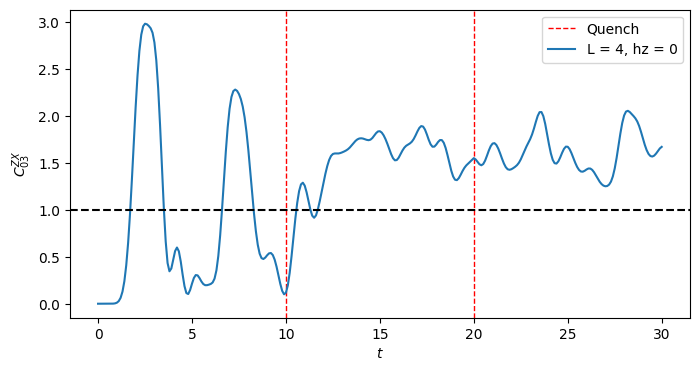

In [26]:
quench_schedule = [(10, 0), (20, 0.5), (30, 0)]

otoc = OTOC.init(L=4, J=1, hx=1, mu='Z', nu='X', i=0, j=3, T=30, tstep=0.1, Dt=10, init_state=0, quench_params=quench_schedule)

otoc.analysis()
otoc.plot_otoc()

In [29]:
quench_schedule = [(10, 0), (20, 0), (30, 0)]
otoc_no_quench = OTOC.init(L=4, J=1, hx=1, mu='Z', nu='X', i=0, j=3, T=30, tstep=0.1, Dt=10, init_state=0, quench_params=quench_schedule)
otoc_no_quench.analysis()
quench_schedule = [(10, 0), (20, 0.5), (30, 0)]
otoc_quench = OTOC.init(L=4, J=1, hx=1, mu='Z', nu='X', i=0, j=3, T=30, tstep=0.1, Dt=10, init_state=0, quench_params=quench_schedule)
otoc_quench.analysis()

Time 10.00: Updating Hamiltonian, hz = 0.5
Time 20.00: Updating Hamiltonian, hz = 0


The below plot compares the OTOC dynamics with and without the quench in $h_z$.

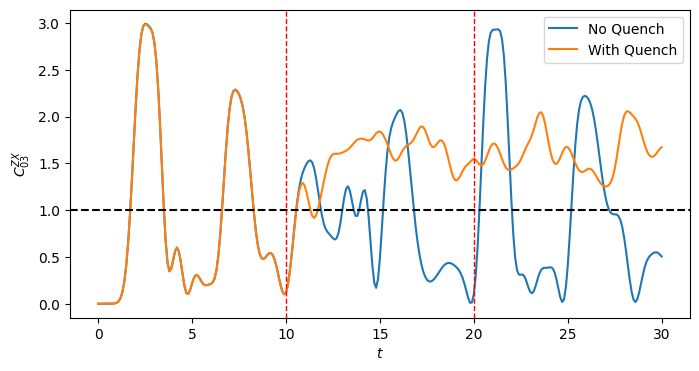

In [30]:
plt.figure(figsize=(8,4))
plt.plot(otoc_no_quench.tlist, otoc_no_quench.normalized_otoc_list, label='No Quench')
plt.plot(otoc_quench.tlist, otoc_quench.normalized_otoc_list, label='With Quench')
plt.axhline(y=1, color='black', linestyle='--')
plt.xlabel('$t$')
plt.ylabel(rf"$C^{{{otoc_no_quench.mu}{otoc_no_quench.nu}}}_{{{otoc_no_quench.i}{otoc_no_quench.j}}}$")
plt.axvline(x=10, color='red', linestyle='--', linewidth=1)
plt.axvline(x=20, color='red', linestyle='--', linewidth=1)
plt.legend()
plt.show()

As you can see above, up until $t=10$, both curves overlap since the Hamiltonian is the same. However, once we introduce the quench, the oscillations of the OTOC with the quench are suppressed compared to the case without the quench, due to the chaotic nature of the system. After the second quench at $t=20$, the system returns to being integrable, but the oscillations do not fully recover to the original amplitude. This can be understood that once the information is scrambled, then it is hard to recover it. This also suggests that OTOC oscillations can be a good indicator of integrable to non-integrable transitions, but the opposite is difficult.